In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import utils as ut

# Introduction
This notebook performs sweeps of `BJ` to identify critical temperature. The sweep is done three times over smaller ranges and higher resolutions to identify the critical temperature to increasing precision. 

## Definitions
* `step`: one iteration of the Metropolis algorithm: propose flipping a random spin and confirming it or reverting to original state
* `sweep`: $N=L^2$ iterations of the Metropolis algorithm
* `block`: A fixed number of sweeps over which spin and energy averages are calculated for identifying whether equilibrium has been reached or not. By default, one block is set to 100 sweeps

## Identification of equilibrium
Each iteration of the sweep is one block. In each iteration, average absolute reduced magnetisation $\left|\tilde m\right| = \frac1N\sum_i^N\left|\sigma_i\right|$ and average energy per spin $E/N$ is computed. If three consecutive blocks change in $|\tilde m|$ and average energy per spin by less than `m_tolerance` and `e_tolerance`, then the system is considered to have equilibrated. Otherwise, the algorithm runs for `max_blocks` iterations.

In [2]:
L = 50 # number of spins_block_block in one side of the square lattice (so total there are N = L^2 spins)

# hamiltonian parameters
H = 0.0 # H = mu_s * B / J

# sweep settings
# BJ_values = np.arange(0.2, 0.71, 0.05)
BJ_values = np.arange(0.3, 0.5, 0.01)

# sweep settings. these settings are kept consistent throughout all runs
num_sweeps_per_block = 500
m_tolerance = 0.01 # absolute tolerance since m can be around 0
e_tolerance = 0.01 # relative tolerance
stable_blocks_required = 3

# Function definitions
## Core sweep function

In [3]:
def run_critical_temperature_sweep(
    BJ_values,
    max_blocks, 
    L=L, 
    H=H, 
    num_sweeps_per_block=num_sweeps_per_block, 
    stable_blocks_required=stable_blocks_required, 
    m_tolerance=m_tolerance, 
    e_tolerance=e_tolerance
    ):

    N = L**2
    steps = num_sweeps_per_block * N

    magnetisations = []
    susceptibilities = []
    equilibration_blocks = []

    for BJ in BJ_values:
        lattice = ut.generate_lattice(L)
        energy = ut.get_energy(lattice, H)

        block_count = 0
        stable_count = 0
        previous_m = None
        previous_e = None

        pbar = tqdm(
            total=max_blocks,
            desc=f"BJ={BJ:.2f}",
            leave=False
        )

        while stable_count < stable_blocks_required and block_count < max_blocks:

            lattice, spins, energies, _ = ut.metropolis(lattice, steps, BJ, H, energy)
            m_block = np.mean(np.abs(spins / N))
            e_block = np.mean(energies / N)

            if previous_m is not None: # previous_m and previous_e should both be None or both be not None
                m_change = abs(m_block - previous_m)
                e_change = abs(e_block - previous_e) / max(abs(previous_e), 1e-8) # denominator is floored at 1e-8 to prevent dividing by zero

                if m_change <= m_tolerance and e_change <= e_tolerance:
                    stable_count += 1
                else:
                    stable_count = 0

            previous_m = m_block
            previous_e = e_block
            energy = energies[-1] # latest lattice is returned by ut.metropolis() but not energy. must update manually

            block_count += 1
            pbar.update(1)
            pbar.set_postfix({
                "blocks": block_count,
                "|m|": f"{m_block:.3f}",
                "E/N": f"{e_block:.3f}",
                "stable": f"{stable_count}/{stable_blocks_required}"
            })

        # separate equilibrium measurement run
        _, spins, _, _ = ut.metropolis(lattice, 10 * steps, BJ, H, energy)
        m = spins / N
        mean_abs_m = np.mean(np.abs(m))
        chi = BJ * N * (np.mean(m**2) - np.mean(np.abs(m))**2)

        magnetisations.append(mean_abs_m)
        susceptibilities.append(chi)
        equilibration_blocks.append(block_count)

        pbar.close()
        print(
            f"BJ={BJ:.2f} equilibrated after "
            f"{block_count} blocks "
            f"(|m|={m_block:.3f}, E/N={e_block:.3f})"
        )

    return magnetisations, susceptibilities, equilibration_blocks


## Plotting functions

In [4]:
def plot_magnetisations(BJ_values, magnetisations):
    plt.figure(figsize=(7, 5))

    plt.plot(BJ_values, magnetisations, marker='o')

    plt.xlabel(r'$\beta J$')
    plt.ylabel(r'$\langle |\tilde{m}| \rangle$')
    plt.title('Magnetisation vs Inverse Temperature')

    plt.grid()
    plt.show()

def plot_susceptibilities(BJ_values, susceptibilities):
    critical_index = np.argmax(susceptibilities)
    BJ_c = BJ_values[critical_index]

    plt.figure(figsize=(7, 5))

    plt.plot(BJ_values, susceptibilities, marker='o')
    plt.axvline(BJ_c, linestyle='--', label=rf'$\beta J_c \approx {BJ_c:.2f}$')

    plt.xlabel(r'$\beta J$')
    plt.ylabel(r'$\tilde{\chi}$')
    plt.title('Magnetic Susceptibility vs Inverse Temperature')

    plt.legend()
    plt.grid()
    plt.show()

    print(f"Estimated critical beta J = {BJ_c:.2f}")

def plot_equilibration_blocks(BJ_values, equilibration_blocks):
    plt.figure(figsize=(7, 5))

    plt.plot(BJ_values, equilibration_blocks, marker='o')

    plt.xlabel(r'$\beta J$')
    plt.ylabel('Sweeps to equilibrium')
    plt.title('Equilibration Blocks vs Inverse Temperature')

    plt.grid()
    plt.show()

# Coarse sweep

In [ ]:
BJ_values = np.arange(0.2, 0.71, 0.05)
max_blocks = 50

magnetisations, susceptibilities, equilibration_blocks = run_critical_temperature_sweep(BJ_values, max_blocks)

BJ=0.20:   0%|          | 0/50 [00:00<?, ?it/s]

BJ=0.20 equilibrated after 4 blocks (|m|=0.025, E/N=-0.427)


BJ=0.25:   0%|          | 0/50 [00:00<?, ?it/s]

BJ=0.25 equilibrated after 4 blocks (|m|=0.032, E/N=-0.556)


BJ=0.30:   0%|          | 0/50 [00:00<?, ?it/s]

...

BJ=0.55 equilibrated after 6 blocks (|m|=0.953, E/N=-1.850)


BJ=0.60:   0%|          | 0/50 [00:00<?, ?it/s]

BJ=0.60 equilibrated after 5 blocks (|m|=0.973, E/N=-1.909)


BJ=0.65:   0%|          | 0/50 [00:00<?, ?it/s]

BJ=0.65 equilibrated after 15 blocks (|m|=0.985, E/N=-1.944)


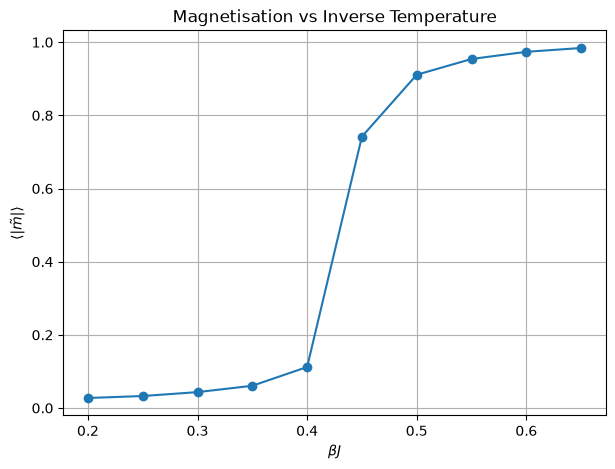

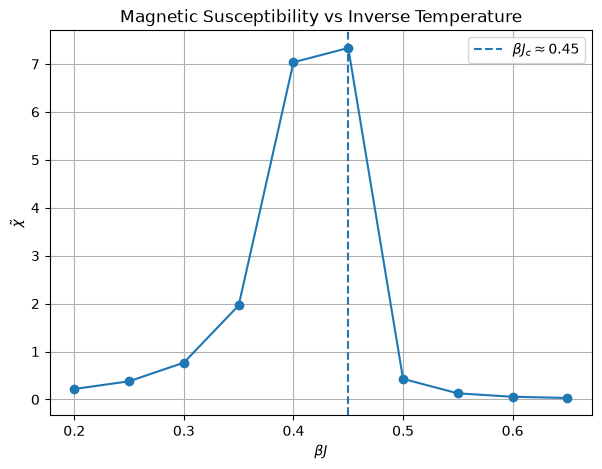

Estimated critical beta J = 0.45


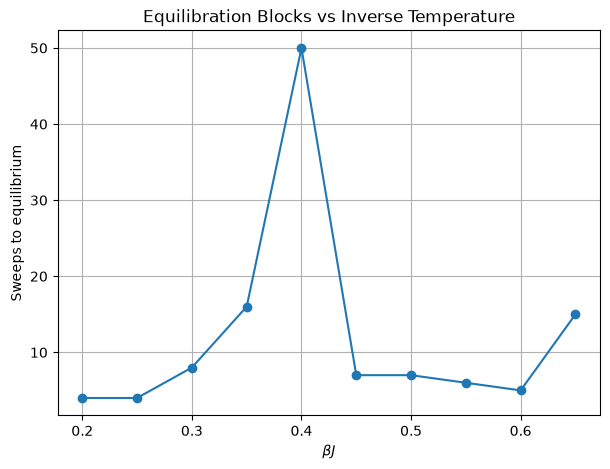

In [6]:
plot_magnetisations(BJ_values, magnetisations)
plot_susceptibilities(BJ_values, susceptibilities)
plot_equilibration_blocks(BJ_values, equilibration_blocks)

# Refined sweep

In [ ]:
BJ_values = np.arange(0.3, 0.51, 0.02)
max_blocks = 125

magnetisations, susceptibilities, equilibration_blocks = run_critical_temperature_sweep(BJ_values, max_blocks)

BJ=0.30:   0%|          | 0/200 [00:00<?, ?it/s]

BJ=0.30 equilibrated after 4 blocks (|m|=0.041, E/N=-0.707)


BJ=0.32:   0%|          | 0/200 [00:00<?, ?it/s]

BJ=0.32 equilibrated after 11 blocks (|m|=0.039, E/N=-0.769)


BJ=0.34:   0%|          | 0/200 [00:00<?, ?it/s]

...

BJ=0.44 equilibrated after 200 blocks (|m|=0.688, E/N=-1.442)


BJ=0.46:   0%|          | 0/200 [00:00<?, ?it/s]

BJ=0.46 equilibrated after 82 blocks (|m|=0.815, E/N=-1.574)


BJ=0.48:   0%|          | 0/200 [00:00<?, ?it/s]

BJ=0.48 equilibrated after 12 blocks (|m|=0.879, E/N=-1.678)


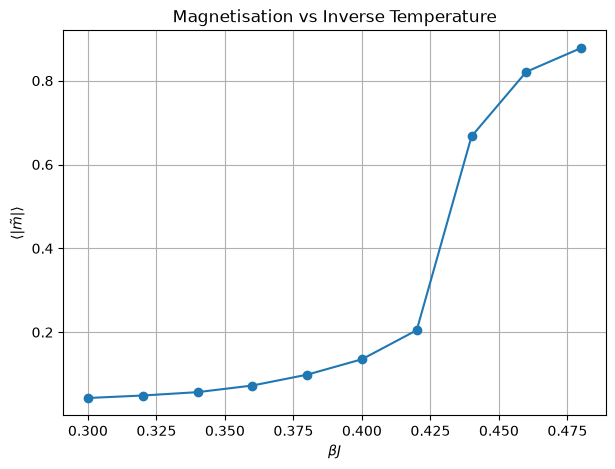

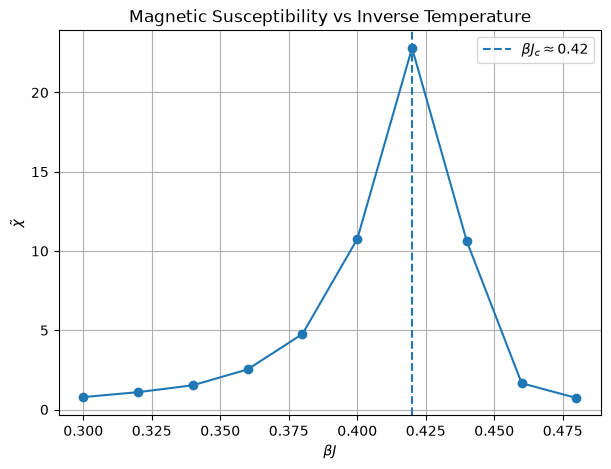

Estimated critical beta J = 0.42


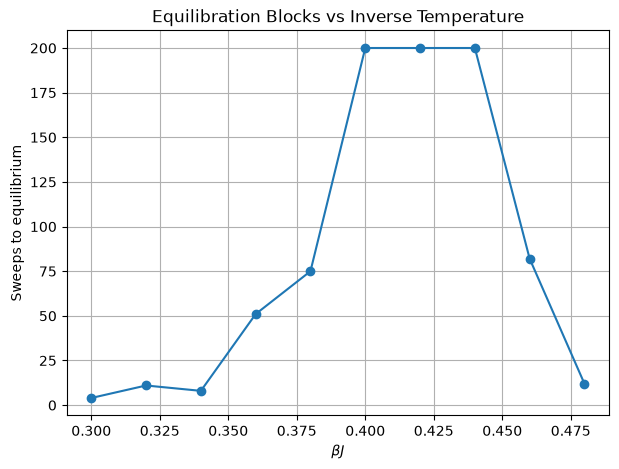

In [8]:
plot_magnetisations(BJ_values, magnetisations)
plot_susceptibilities(BJ_values, susceptibilities)
plot_equilibration_blocks(BJ_values, equilibration_blocks)

# Finding critical temperature

In [11]:
BJ_values = np.arange(0.4, 0.451, 0.002)
max_blocks = 500

all_susceptibilities = []

for _ in range(5):
    _, susceptibilities, _ = run_critical_temperature_sweep(BJ_values, max_blocks)
    all_susceptibilities.append(susceptibilities)

mean_susceptibilities = np.mean(all_susceptibilities, axis=0)
plot_susceptibilities(BJ_values, mean_susceptibilities)

BJ=0.40:   0%|          | 0/500 [00:00<?, ?it/s]

SystemError: CPUDispatcher(<function metropolis at 0x11b5bd760>) returned a result with an exception set